# Sprint 4 — Causal Emergence Computation

Computes the causal-emergence coefficient $\Psi$, its higher-order variants, and the three
novel giant-killing metrics for every upset/control match in the corpus.

**Sprint 4 deliverables → where they live in this notebook**

| Sprint 4 activity | Section |
|---|---|
| Compute $\Psi$ for all matches, windows, macro features | §2 (macro features), §4 ($\Psi$), §7–§8 (batch) |
| Compute for orders $\ell = 1, 2, 3$ (subsampling for higher orders) | §4.2, §4.4 ($\ell{=}3$ subsampling + bias measurement) |
| Calculate novel metrics (EAI, DC, SRR) | §5 |
| Diagnostic checks and outlier detection | §6 |
| **Ψ trajectories** (deliverable) | §9 |
| **Novel metrics** (deliverable) | columns of `{match_id}_caus.*` |
| **Computation log** (deliverable) | `data/caus_emg/computation_log.csv` + per-match `_caus_log.json` |

---

## Theory

Following Rosas et al. (2020), for microscopic features $X_t=\{X^1_t,\dots,X^n_t\}$ and a
supervenient macroscopic feature $V_t$, the practical criterion for causal emergence at order
$k$ is

$$\Psi^{(k)}_{t,t'}(V) \;:=\; I(V_t;V_{t'}) \;-\; \sum_{|\alpha|=k} I\!\left(X^{\alpha}_t;V_{t'}\right),$$

with $\Psi^{(k)}>0$ *sufficient* for $V_t$ to be causally emergent. Here $\alpha$ ranges over
player subsets of size $k$, so $\ell=1$ is individual players, $\ell=2$ pairs, $\ell=3$ triples
(Giant_Killing §3.1–3.3). $\Psi>0$ is synergy-dominated, $\Psi<0$ redundancy-dominated.

The novel metrics (Giant_Killing §3.4):

$$\mathrm{EAI}(t)=\frac{\Psi_{\text{und}}(t)-\Psi_{\text{fav}}(t)}{\Psi_{\text{und}}(t)+\Psi_{\text{fav}}(t)+\epsilon},
\qquad
\mathrm{DC}=\frac{I(V_{\text{und}};V_{\text{fav}})}{H(V_{\text{fav}})},
\qquad
\mathrm{SRR}=\frac{\max(0,\Psi)}{|\min(0,\Psi)|+\epsilon}.$$

Each is emitted **exactly as specified**, alongside a stabilised companion — see §5 for why the
literal forms are numerically fragile on this data and what the companions fix.

---

## Data flow

```
data/ksg/{match_id}_ksg.{csv,parquet}      <- Sprint 3 output: the driver manifest
        |   (match_id, outcome, team, window_start, I_macro, I_micro_sum, psi)
        |
        +-- match ids, outcome labels, team names, the 60 s window grid, and the
        |   Sprint-3 psi (carried through and reconciled in section 6)
        |
        +-- micro X_t / macro V_t rebuilt for those exact matches & windows from
            ../statsbomb-360 (section 3) -- required because per-macro-feature Psi,
            the l=2,3 sums, and the cross-team DC term cannot be recovered from the
            aggregated Sprint-3 columns
        |
        v
data/caus_emg/{match_id}_caus.{csv,parquet}
data/caus_emg/computation_log.csv
```

Note on paths: the Sprint-3 files live in `src/data/ksg/`, so outputs mirror that layout in
`src/data/caus_emg/` (this notebook runs with `src/` as the working directory, exactly like
`ksg_impl.ipynb`). Change `CAUS_DIR` below to move them.

In [1]:
# === Imports & configuration =================================================
import warnings; warnings.filterwarnings("ignore")
import os; os.environ.setdefault("PYTHONWARNINGS", "ignore")
import os, glob, json, time, itertools, re, unicodedata, traceback
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.special import digamma, gamma as gamma_fn
from joblib import Parallel, delayed

try:
    import matplotlib.pyplot as plt
    _HAS_PLT = True
except Exception:
    _HAS_PLT = False

# ---- paths ------------------------------------------------------------------
KSG_DIR      = os.path.join("data", "ksg")        # Sprint 3 input
CAUS_DIR     = os.path.join("data", "caus_emg")   # Sprint 4 output
SB_360_DIR   = os.path.join("..", "statsbomb-360", "data", "three-sixty")
SB_MATCH_DIR = os.path.join("..", "statsbomb-360", "data", "matches")
SB_EVENTS_DIR= os.path.join("..", "open-data", "data", "events")
UPSET_XLSX, CONTROL_XLSX = "upset_list.xlsx", "control_lists.xlsx"
os.makedirs(CAUS_DIR, exist_ok=True)

# ---- estimator / window parameters (must match Sprint 3) --------------------
K_DEFAULT   = 4        # KSG neighbours
WINDOW_SEC  = 60       # 60 s analysis window
LAG         = 1        # 1-step-ahead (t' = t+1)
MIN_SAMPLES = 4 * K_DEFAULT   # a window needs >= 16 clean frames
STANDARDIZE = True     # z-score every dimension inside each window (see section 1.2)
JITTER      = 1e-10    # tie-breaking noise, in standardised units (Kraskov et al. 2004 II.B)

# ---- emergence orders -------------------------------------------------------
ORDERS         = (1, 2, 3)
MACRO_FEATURES = ["V_com", "V_dist", "V_cvel", "V_cdist", "V_all", "V_fast"]
#   V_com   center of mass (2-d)          V_cvel  clustering, velocity similarity (1-d)
#   V_dist  mean rel. distance to centre  V_cdist clustering, inverse distance (1-d)
#   V_all   all four jointly (5-d)        V_fast  [V_com, V_dist] = the Sprint-3 macro (3-d)

# ---- l=3 subsampling (combinatorial explosion control) ----------------------
L3_STRATEGY = "proximal"   # "proximal" | "random" | "full"
L3_RADIUS   = 25.0         # metres: triples whose members are pairwise within this
L3_MAX      = 60           # hard cap on triples per window
L3_SEED     = 0
HO_STRIDE   = 1            # compute l>=2 on every HO_STRIDE-th window (1 = all)

# ---- metric parameters ------------------------------------------------------
EPS         = 1e-9         # epsilon in EAI / SRR
SRR_ROLL    = 30           # windows in the rolling SRR
OUTLIER_Z   = 5.0          # robust (MAD) z threshold for outlier flagging
EAI_DENOM_MIN = 1e-3       # |Psi_u + Psi_f| below this -> EAI flagged unstable

# ---- batch control ----------------------------------------------------------
MAX_MATCHES = None         # None = every match in data/ksg
OVERWRITE   = False        # False = resume (skip matches already written)
MATCH_JOBS  = max(1, (os.cpu_count() or 4) - 1)   # matches computed in parallel

CENTRE = np.array([60.0, 40.0]); MAX_OUTFIELD = 10
RED_CARDS = {"Red Card", "Second Yellow"}

print(f"Sprint 4 config: orders={ORDERS}, macro features={len(MACRO_FEATURES)}, k={K_DEFAULT}, "
      f"window={WINDOW_SEC}s, standardize={STANDARDIZE}")
print(f"l=3 subsampling: {L3_STRATEGY} (radius {L3_RADIUS} m, cap {L3_MAX}) | "
      f"{MATCH_JOBS} matches in parallel")
print(f"in  {KSG_DIR}/  ->  out {CAUS_DIR}/")

Sprint 4 config: orders=(1, 2, 3), macro features=6, k=4, window=60s, standardize=True
l=3 subsampling: proximal (radius 25.0 m, cap 60) | 7 matches in parallel
in  data/ksg/  ->  out data/caus_emg/


## 1. Estimators

### 1.1 Mutual information and entropy

$\Psi$ needs mutual information; the Disruption Coefficient additionally needs a differential
entropy.

* `ksg_mi` — the Sprint-3 KSG #1 estimator (k-d trees, Chebyshev norm), kept verbatim so the
  Sprint-3 reconciliation in §6 is exact.
* `ksg_from_dist` / `ksg_batch_from_dist` — the *same* estimator evaluated from precomputed
  Chebyshev distance matrices. Windows here hold ~59 samples, for which building a k-d tree per
  estimate is pure overhead, and the micro-side distances can be shared across all six macro
  features. The cell below asserts the two agree to machine precision; §4.3 shows the speed-up.
* `kl_entropy` — Kozachenko–Leonenko differential entropy, supplying $H(V_{\text{fav}})$ for DC.

### 1.2 Two estimator details that matter on this data

**Standardisation.** KSG #1 uses the Chebyshev (max) norm, so a joint feature vector is
dominated by whichever dimension has the largest numerical spread. Raw macro features here span
$\sigma(V_{\text{com}})\approx19$ m against $\sigma(V_{\text{cdist}})\approx0.10$ — un-scaled,
the 5-d `V_all` reduces to `V_com` and the clustering features contribute nothing (demonstrated
in §4.3). Every dimension is therefore z-scored within its window before estimation, with $V_t$
and $V_{t'}$ sharing one scaler since they are the same variable at two times. MI is invariant
to this transform in theory; the estimator is not.

**Ties.** StatsBomb 360 is event-sampled, so the 1 Hz grid interpolates linearly between events
and the velocity-derived macro feature `V_cvel` is piecewise constant — long runs of identical
values. With an absolute neighbour tolerance those runs give $\epsilon_i=0$, a neighbour count
of $-1$, and $\psi(0)=-\infty$: `V_cvel` returned `inf` before this was addressed. The estimator
uses a *relative* tolerance, clamps counts at zero, and adds `JITTER` of tie-breaking noise in
standardised units, which is Kraskov et al.'s own recommendation (§II.B).

In [2]:
_REL_TOL = 1.0 - 1e-12          # relative neighbour tolerance (strict inequality, tie-safe)

def _as2d(A):
    A = np.asarray(A, float)
    return A[:, None] if A.ndim == 1 else A

def ksg_mi(X, Y, k=K_DEFAULT):
    """KSG estimator #1 (Kraskov et al. 2004) via k-d trees. Verbatim Sprint 3."""
    X, Y = _as2d(X), _as2d(Y)
    N = len(X)
    if N <= k + 1:
        return np.nan
    Z = np.hstack([X, Y])
    eps = cKDTree(Z).query(Z, k=k + 1, p=np.inf)[0][:, k]
    nx = np.asarray(cKDTree(X).query_ball_point(X, eps - 1e-12, p=np.inf, return_length=True)) - 1
    ny = np.asarray(cKDTree(Y).query_ball_point(Y, eps - 1e-12, p=np.inf, return_length=True)) - 1
    return digamma(k) - np.mean(digamma(nx + 1) + digamma(ny + 1)) + digamma(N)

def cheb_dist(A):
    """(N,d) -> (N,N) Chebyshev distance matrix."""
    A = _as2d(A)
    return np.max(np.abs(A[:, None, :] - A[None, :, :]), axis=2)

def ksg_from_dist(Dx, Dy, k=K_DEFAULT):
    """KSG #1 from precomputed Chebyshev distance matrices."""
    N = Dx.shape[0]
    if N <= k + 1:
        return np.nan
    eps = np.partition(np.maximum(Dx, Dy), k, axis=1)[:, k]
    thr = (eps * _REL_TOL)[:, None]
    nx = np.maximum((Dx < thr).sum(1) - 1, 0)
    ny = np.maximum((Dy < thr).sum(1) - 1, 0)
    return digamma(k) - np.mean(digamma(nx + 1) + digamma(ny + 1)) + digamma(N)

def ksg_batch_from_dist(Dxs, Dy, k=K_DEFAULT):
    """Many X against one Y.  Dxs (S,N,N), Dy (N,N) -> (S,) MI estimates.

    This is what makes the corpus tractable: the micro-side distance matrices depend only on
    the window, so they are built once and reused for every macro feature and every order.
    """
    S, N, _ = Dxs.shape
    if N <= k + 1:
        return np.full(S, np.nan)
    eps = np.partition(np.maximum(Dxs, Dy), k, axis=2)[:, :, k]
    thr = (eps * _REL_TOL)[:, :, None]
    nx = np.maximum((Dxs < thr).sum(2) - 1, 0)
    ny = np.maximum((Dy[None] < thr).sum(2) - 1, 0)
    return digamma(k) - (digamma(nx + 1) + digamma(ny + 1)).mean(1) + digamma(N)

def kl_entropy(X, k=K_DEFAULT):
    """Kozachenko-Leonenko differential entropy in nats (Euclidean norm).
    H = -psi(k) + psi(N) + log(c_d) + (d/N) sum log r_i,  c_d = volume of the unit d-ball."""
    X = _as2d(X)
    N, d = X.shape
    if N <= k + 1:
        return np.nan
    r = np.maximum(cKDTree(X).query(X, k=k + 1)[0][:, k], 1e-12)
    log_cd = (d / 2.0) * np.log(np.pi) - np.log(gamma_fn(d / 2.0 + 1))
    return -digamma(k) + digamma(N) + log_cd + d * np.mean(np.log(r))

def zscore(A, ref=None, jitter=JITTER, rng=None):
    """Standardise each column; constant columns map to zero.  `ref` supplies shared
    statistics (so V_t and V_t' share one scaler).  Optional tie-breaking noise."""
    A = _as2d(A)
    if not STANDARDIZE:
        return A
    R = A if ref is None else _as2d(ref)
    mu, sd = R.mean(0), R.std(0)
    Z = (A - mu) / np.where(sd > 0, sd, 1.0)
    if jitter and rng is not None:
        Z = Z + rng.normal(0.0, jitter, Z.shape)
    return Z

In [3]:
# === Validation ==============================================================
_rng = np.random.default_rng(0)

# (a) KSG MI against the closed-form Gaussian value
_rows = []
for _rho in [0.0, 0.3, 0.6, 0.9]:
    _d = _rng.multivariate_normal([0, 0], [[1, _rho], [_rho, 1]], size=4000)
    _rows.append(dict(rho=_rho, MI_true=round(-0.5 * np.log(1 - _rho ** 2), 4),
                      MI_est=round(ksg_mi(_d[:, 0], _d[:, 1]), 4)))
_mi_val = pd.DataFrame(_rows)
print("KSG MI vs closed-form Gaussian MI (N=4000, k=4):")
display(_mi_val)

# (b) Kozachenko-Leonenko entropy against the standard-normal value
_ent = []
for _dd in [1, 2, 3, 5]:
    _s = _rng.standard_normal((8000, _dd))
    _ent.append(dict(d=_dd, H_true=round(0.5 * _dd * np.log(2 * np.pi * np.e), 4),
                     H_est=round(kl_entropy(_s), 4)))
_h_val = pd.DataFrame(_ent)
print("Kozachenko-Leonenko entropy vs standard-normal entropy (N=8000, k=4):")
display(_h_val)

# (c) matrix and batched estimators are the SAME estimator as the tree version
_A = _rng.standard_normal((120, 6))
_B = _A[:, :2] * 0.7 + _rng.standard_normal((120, 2)) * 0.5
_Dy = cheb_dist(_B)
_tree  = np.array([ksg_mi(_A[:, [i]], _B) for i in range(6)] + [ksg_mi(_A, _B)])
_mat   = np.array([ksg_from_dist(cheb_dist(_A[:, [i]]), _Dy) for i in range(6)]
                  + [ksg_from_dist(cheb_dist(_A), _Dy)])
_batch = ksg_batch_from_dist(np.stack([cheb_dist(_A[:, [i]]) for i in range(6)]
                                      + [cheb_dist(_A)]), _Dy)
print(f"tree vs matrix : max |diff| = {np.abs(_tree - _mat).max():.2e}")
print(f"tree vs batched: max |diff| = {np.abs(_tree - _batch).max():.2e}")
assert np.allclose(_tree, _mat) and np.allclose(_tree, _batch)

# (d) the tie pathology that produced inf, and the fix
_tied = np.repeat(np.array([[0.0], [1.0], [2.0]]), 20, axis=0)
_y    = _rng.standard_normal((60, 1))
print(f"\npiecewise-constant input (the V_cvel case): Sprint-3 estimator -> "
      f"{ksg_mi(_tied, _y):.4f} | tie-safe estimator -> "
      f"{ksg_from_dist(cheb_dist(_tied), cheb_dist(_y)):.4f}")
print(f"\nmax |MI error| = {(_mi_val.MI_est - _mi_val.MI_true).abs().max():.4f} nats | "
      f"max |H error| = {(_h_val.H_est - _h_val.H_true).abs().max():.4f} nats")

KSG MI vs closed-form Gaussian MI (N=4000, k=4):


,rho,MI_true,MI_est
0,0.0,-0.0000,-0.0090
1,0.3,0.0472,0.0619
2,0.6,0.2231,0.2339
3,0.9,0.8304,0.8476


Kozachenko-Leonenko entropy vs standard-normal entropy (N=8000, k=4):


,d,H_true,H_est
0,1,1.4189,1.4589
1,2,2.8379,2.8309
2,3,4.2568,4.2225
3,5,7.0947,7.0571


tree vs matrix : max |diff| = 0.00e+00
tree vs batched: max |diff| = 0.00e+00

piecewise-constant input (the V_cvel case): Sprint-3 estimator -> -0.0601 | tie-safe estimator -> -0.0601

max |MI error| = 0.0172 nats | max |H error| = 0.0400 nats


## 2. Macroscopic features

Four macro features (Giant_Killing §3.5, Table 2), all functions of the same micro state
$X_t=\{(x_i,y_i)\}_{i=1}^{P}$ so that supervenience holds:

| Feature | Symbol | Definition |
|---|---|---|
| Centre of mass | `V_com` | $\frac1P\sum_i (x_i,y_i)$ |
| Relative distance to centre | `V_dist` | $\frac1P\sum_i \lVert (x_i,y_i)-(60,40)\rVert$ |
| Clustering, inverse distance | `V_cdist` | weighted global clustering coefficient, $w_{uv}=1/d_{uv}$ |
| Clustering, velocity similarity | `V_cvel` | weighted global clustering coefficient, $w_{uv}=S_uS_v(\cos\Delta\theta+1)$ |

Two composites are added: `V_all` (all four jointly, 5-d) and `V_fast` (`V_com` + `V_dist`,
3-d) — the latter is exactly the macro state Sprint 3 used, so it is the direct comparator.

`ksg_impl.ipynb` built the clustering coefficients with a per-frame `networkx` graph, far too
slow for the full corpus (~8500 frames × 2 teams × 136 matches). `onnela_clustering` is a
vectorised implementation of the same Onnela weighted clustering coefficient that
`nx.average_clustering(..., weight=...)` computes; the cell asserts they agree.

In [4]:
def onnela_clustering(W):
    """Mean Onnela weighted local clustering coefficient for a stack of graphs.

    W : (T, n, n) symmetric, non-negative, zero diagonal.  Returns (T,).
    c_u = [k_u(k_u-1)]^-1 * sum_{v,w} (w_uv_hat w_uw_hat w_vw_hat)^(1/3),
    weights normalised by the graph maximum -- i.e. networkx's definition.
    """
    W = np.asarray(W, float)
    T = W.shape[0]
    mx = W.reshape(T, -1).max(1)
    mx[mx <= 0] = 1.0
    Wh = np.cbrt(W / mx[:, None, None])          # cube root of normalised weights
    deg = (W > 0).sum(2).astype(float)           # degree of the unweighted skeleton
    tri = np.einsum("tij,tjk,tki->ti", Wh, Wh, Wh)
    den = deg * (deg - 1.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.where(den > 0, tri / den, 0.0)
    return c.mean(1)

def _pairwise_weights(pos, vel):
    """(T,P,P) inverse-distance and velocity-similarity weight stacks."""
    D = np.sqrt(((pos[:, :, None, :] - pos[:, None, :, :]) ** 2).sum(-1))
    with np.errstate(divide="ignore", invalid="ignore"):
        Wd = np.where(D > 1e-9, 1.0 / D, 0.0)
    Wd = np.nan_to_num(Wd, nan=0.0, posinf=0.0)

    sp  = np.sqrt((vel ** 2).sum(-1))                    # speed
    ang = np.arctan2(vel[..., 1], vel[..., 0])           # heading
    Wv  = sp[:, :, None] * sp[:, None, :] * (np.cos(ang[:, :, None] - ang[:, None, :]) + 1.0)
    Wv  = np.nan_to_num(Wv, nan=0.0, posinf=0.0, neginf=0.0)

    idx = np.arange(pos.shape[1])
    Wd[:, idx, idx] = 0.0
    Wv[:, idx, idx] = 0.0
    return Wd, Wv

def macro_features(pos, vel):
    """pos, vel : (T, P, 2) -> dict of macro arrays, each (T, d)."""
    V_com   = np.nanmean(pos, axis=1)
    V_dist  = np.nanmean(np.sqrt(((pos - CENTRE) ** 2).sum(2)), axis=1, keepdims=True)
    Wd, Wv  = _pairwise_weights(pos, vel)
    V_cdist = onnela_clustering(Wd)[:, None]
    V_cvel  = onnela_clustering(Wv)[:, None]
    out = dict(V_com=V_com, V_dist=V_dist, V_cvel=V_cvel, V_cdist=V_cdist)
    out["V_all"]  = np.hstack([V_com, V_dist, V_cvel, V_cdist])   # 5-d joint macro
    out["V_fast"] = np.hstack([V_com, V_dist])                    # 3-d, == Sprint-3 macro
    return out

# --- validation: vectorised == networkx --------------------------------------
try:
    import networkx as nx
    _r = np.random.default_rng(4)
    _W = _r.random((5, 9, 9)); _W = (_W + _W.transpose(0, 2, 1)) / 2
    _W[:, np.arange(9), np.arange(9)] = 0.0
    _W[_W < 0.25] = 0.0                                  # some sparsity
    _mine = onnela_clustering(_W)
    _ref  = np.array([nx.average_clustering(nx.from_numpy_array(_W[t]), weight="weight")
                      for t in range(5)])
    print(f"onnela_clustering vs networkx.average_clustering: max |diff| = "
          f"{np.abs(_mine - _ref).max():.2e}  -> identical estimator, vectorised over frames")
    assert np.allclose(_mine, _ref, atol=1e-10)
except ImportError:
    print("networkx not installed; skipping the equivalence check")

onnela_clustering vs networkx.average_clustering: max |diff| = 2.22e-16  -> identical estimator, vectorised over frames


## 3. Inputs: the Sprint-3 manifest and the reconstructed feature bundles

### 3.1 What comes from `data/ksg/`

The Sprint-3 files define the *work list* for this sprint: which matches, which teams, which
60 s windows, and the upset/control label. They also carry `psi`, the $\ell=1$ coefficient
computed on the 3-d macro `V_fast` — reproduced here and reconciled in §6.

### 3.2 What has to be rebuilt, and why

`{match_id}_ksg.csv` stores only the *aggregate* `I_macro`, `I_micro_sum`, `psi` per window.
Three Sprint-4 quantities are not recoverable from those columns:

* **$\Psi$ per macro feature** — Sprint 3 collapsed the macro state into one vector.
* **$\Psi^{(2)}, \Psi^{(3)}$** — the pair/triple sums are different sums, not a transform of
  the $\ell=1$ sum.
* **DC** — needs $I(V_{\text{und}};V_{\text{fav}})$, a cross-team term never computed.

So the micro/macro state is reconstructed for exactly the matches and windows named by the
KSG manifest, using the same StatsBomb-360 pipeline as `ksg_impl.ipynb` §7a (1 Hz grid,
finite-difference velocities, goalkeepers and post-red-card frames dropped). One deviation:
both teams are placed on a **single common absolute-second grid** so that a `window_start`
means the same instant for both — required for EAI and DC. §6 verifies the reconstruction
reproduces the Sprint-3 `psi` exactly.

In [5]:
# === 3a. StatsBomb readers (mirrors ksg_impl.ipynb 7a) =======================
def read_360(mid):
    p = os.path.join(SB_360_DIR, f"{mid}.json")
    return json.load(open(p)) if os.path.exists(p) else None

def read_events(mid):
    p = os.path.join(SB_EVENTS_DIR, f"{mid}.json")
    return json.load(open(p)) if os.path.exists(p) else None

_MATCH_INDEX = None
def match_index():
    global _MATCH_INDEX
    if _MATCH_INDEX is None:
        _MATCH_INDEX = {}
        for path in glob.glob(os.path.join(SB_MATCH_DIR, "*", "*.json")):
            for m in json.load(open(path)):
                _MATCH_INDEX[m["match_id"]] = m
    return _MATCH_INDEX

def match_teams(mid):
    m = match_index().get(int(mid))
    if not m:
        return None, None
    return m["home_team"]["home_team_name"], m["away_team"]["away_team_name"]

def _events_tbl(ev):
    r = []
    for e in ev:
        r.append(dict(event_uuid=e["id"], period=e["period"], minute=e["minute"], second=e["second"],
                      team=(e.get("team") or {}).get("name"),
                      poss_team=(e.get("possession_team") or {}).get("name"),
                      bb=(e.get("bad_behaviour") or {}).get("card", {}).get("name"),
                      fc=(e.get("foul_committed") or {}).get("card", {}).get("name")))
    d = pd.DataFrame(r)
    d["t_sec"] = (d.period - 1) * 45 * 60 + d.minute * 60 + d.second
    return d

def build_bundle(mid):
    """match_id -> {team: dict(grid, pos, vel, macro, t_start)} on a COMMON 1 Hz grid.

    Steps 1-5 of the Giant_Killing pipeline: event-aligned timestamps, 1 Hz resampling,
    finite-difference velocities, goalkeeper removal, red-card truncation.
    """
    fr, ev = read_360(mid), read_events(mid)
    home, away = match_teams(mid)
    if not fr or not ev or home is None:
        return None
    e = _events_tbl(ev)

    red = {}                                                   # first red card per team
    for _, rr in e[(e.bb.isin(RED_CARDS)) | (e.fc.isin(RED_CARDS))].iterrows():
        if rr.team:
            red[rr.team] = min(red.get(rr.team, np.inf), rr.t_sec)

    frows = [(f["event_uuid"], p["teammate"], p["keeper"], p["location"][0], p["location"][1])
             for f in fr for p in f["freeze_frame"]]
    ft = pd.DataFrame(frows, columns=["event_uuid", "teammate", "keeper", "x", "y"])
    j = (ft.merge(e[["event_uuid", "t_sec", "poss_team"]], on="event_uuid", how="left")
           .dropna(subset=["t_sec", "x", "y"]))
    j["team"] = np.where(j.teammate, j.poss_team, np.where(j.poss_team == home, away, home))
    j = j.dropna(subset=["team"])
    j = j[~j.keeper]                                           # filter goalkeepers
    if red:                                                    # filter post-red-card frames
        keep = np.ones(len(j), bool)
        for tm, tred in red.items():
            keep &= ~((j.team.values == tm) & (j.t_sec.values >= tred))
        j = j[keep]
    if j.empty:
        return None

    t0, t1 = int(np.floor(j.t_sec.min())), int(np.ceil(j.t_sec.max()))
    grid = np.arange(t0, t1 + 1, 1.0)                          # COMMON grid for both teams
    out = {}
    for tm in j.team.dropna().unique():
        g = j[j.team == tm].sort_values(["t_sec", "x", "y"]).copy()
        g["pid"] = g.groupby("t_sec").cumcount() + 1
        g = g[g.pid <= MAX_OUTFIELD]
        if len(g) == 0:
            continue
        P, T = int(g.pid.max()), len(grid)
        pos = np.full((T, P, 2), np.nan)
        for pid, pg in g.groupby("pid"):
            pg = pg.drop_duplicates("t_sec").sort_values("t_sec")
            if len(pg) < 2:
                continue
            xs = np.interp(grid, pg.t_sec, pg.x)
            ys = np.interp(grid, pg.t_sec, pg.y)
            inr = (grid >= pg.t_sec.min()) & (grid <= pg.t_sec.max())
            xs[~inr] = np.nan; ys[~inr] = np.nan
            pos[:, pid - 1, 0] = xs; pos[:, pid - 1, 1] = ys
        vel = np.full_like(pos, np.nan)
        vel[1:] = np.diff(pos, axis=0)                         # 1 Hz finite differences
        out[tm] = dict(grid=grid, pos=pos, vel=vel, macro=macro_features(pos, vel),
                       t_start=float(g.t_sec.min()))
    return out or None

print("readers ready: read_360, read_events, match_teams, build_bundle")

readers ready: read_360, read_events, match_teams, build_bundle


In [6]:
# === 3b. The KSG manifest: matches, teams, windows, outcome, Sprint-3 psi =====
def ksg_match_ids(ksg_dir=KSG_DIR):
    return sorted({int(os.path.basename(p).split("_")[0])
                   for p in glob.glob(os.path.join(ksg_dir, "*_ksg.csv"))
                   + glob.glob(os.path.join(ksg_dir, "*_ksg.parquet"))})

def load_ksg(mid, ksg_dir=KSG_DIR):
    """Prefer the parquet (typed); fall back to the csv."""
    pq  = os.path.join(ksg_dir, f"{mid}_ksg.parquet")
    csv = os.path.join(ksg_dir, f"{mid}_ksg.csv")
    if os.path.exists(pq):
        try:
            return pd.read_parquet(pq)
        except Exception:
            pass
    return pd.read_csv(csv) if os.path.exists(csv) else None

KSG_IDS = ksg_match_ids()
_m0 = load_ksg(KSG_IDS[0])
print(f"{len(KSG_IDS)} matches in {KSG_DIR}/")
print(f"example {KSG_IDS[0]}: {len(_m0)} rows, teams={sorted(_m0.team.unique())}, "
      f"outcome={_m0.outcome.iloc[0]}, windows/team={_m0.groupby('team').size().iloc[0]}, "
      f"window_start step={int(np.diff(sorted(_m0.window_start.unique()))[0])}s")
display(_m0.head(3))

136 matches in data/ksg/
example 3764440: 1644 rows, teams=['Barcelona', 'Elche'], outcome=control, windows/team=822, window_start step=10s


,match_id,outcome,team,window_start,I_macro,I_micro_sum,psi
0,3764440,control,Barcelona,0,1.012924,10.430970,-9.418046
1,3764440,control,Barcelona,10,0.998582,9.645837,-8.647255
2,3764440,control,Barcelona,20,1.317961,15.249248,-13.931286


In [7]:
# === 3c. Underdog / favourite roles from the Sprint-1 match lists ============
COMP_MAP = {
    "WC 2022": "FIFA World Cup 2022", "Euro 2024": "UEFA Euro 2024", "Euro 2020": "UEFA Euro 2020",
    "AFCON 2023": "African Cup of Nations 2023", "WWC 2023": "Women's World Cup 2023",
    "Women's Euro 2022": "UEFA Women's Euro 2022", "Women's Euro 2025": "UEFA Women's Euro 2025",
    "La Liga 20/21": "La Liga 2020/2021", "Ligue 1 22/23": "Ligue 1 2022/2023",
    "Ligue 1 21/22": "Ligue 1 2021/2022", "MLS 2023": "Major League Soccer 2023",
    "Bundesliga 23/24": "1. Bundesliga 2023/2024"}
_ALIASES = {"ir iran": "iran", "korea republic": "south korea", "republic of korea": "south korea",
    "cote d'ivoire": "ivory coast", "united states": "usa", "turkiye": "turkey",
    "czechia": "czech republic", "the gambia": "gambia", "dr congo": "congo dr", "china pr": "china"}

def _norm(s):
    s = re.sub(r"\s*\[.*?\]", "", str(s)).lower().strip()
    s = re.sub(r"['’‘]", "'", s)
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    s = re.sub(r"\bwomen's\b|\bwomen\b", "", s)
    s = re.sub(r"\bfc\b|\bcf\b", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return _ALIASES.get(s, s)

def build_role_map():
    """match_id -> dict(outcome, favourite, underdog, ...) using StatsBomb team names."""
    local360 = {int(os.path.splitext(os.path.basename(p))[0])
                for p in glob.glob(os.path.join(SB_360_DIR, "*.json"))}
    index = {}
    for m in match_index().values():
        comp = f"{m['competition']['competition_name']} {m['season']['season_name']}"
        key = (comp, frozenset({_norm(m["home_team"]["home_team_name"]),
                                _norm(m["away_team"]["away_team_name"])}))
        index.setdefault(key, []).append(m["match_id"])

    roles = {}
    for path, outcome, sheet in [(UPSET_XLSX, "upset", "upsets"),
                                 (CONTROL_XLSX, "control", "control_lists")]:
        for _, r in pd.read_excel(path, sheet_name=sheet).iterrows():
            comp = COMP_MAP.get(r["competition"])
            if not comp:
                continue
            cands = index.get((comp, frozenset({_norm(r["home"]), _norm(r["away"])})), [])
            with360 = [m for m in cands if m in local360]
            mid = with360[0] if with360 else (cands[0] if cands else None)
            if mid is None or mid in roles:
                continue
            sb = match_index()[mid]
            names = [sb["home_team"]["home_team_name"], sb["away_team"]["away_team_name"]]
            lookup = {_norm(n): n for n in names}
            fav, und = lookup.get(_norm(r["favourite"])), lookup.get(_norm(r["underdog"]))
            if fav is None or und is None:
                continue
            roles[mid] = dict(outcome=outcome, favourite=fav, underdog=und,
                              competition=r["competition"],
                              fav_rank=int(r["fav_rank"]), und_rank=int(r["und_rank"]))
    return roles

ROLES = build_role_map()
_cov = sum(m in ROLES for m in KSG_IDS)
print(f"role map: {len(ROLES)} fixtures resolved; covers {_cov}/{len(KSG_IDS)} KSG matches")
if _cov < len(KSG_IDS):
    print("  unmapped (EAI/DC will be NaN):", [m for m in KSG_IDS if m not in ROLES][:10])
display(pd.DataFrame(ROLES).T.head(3))

role map: 160 fixtures resolved; covers 136/136 KSG matches


,outcome,favourite,underdog,competition,fav_rank,und_rank
3773428,upset,Barcelona,Cádiz,La Liga 20/21,3,12
3920408,upset,Côte d'Ivoire,Equatorial Guinea,AFCON 2023,49,88
3920403,upset,Mauritania,Angola,AFCON 2023,105,117


## 4. $\Psi$ at orders $\ell = 1, 2, 3$

### 4.1 Window construction

A window starting at index $s$ uses frames $[s,\,s+60)$; $V_t$ and $X_t$ are frames
$[s,\,s+59)$ and $V_{t'}$ is frames $[s+1,\,s+60)$ — the Sprint-3 convention.

A **single validity mask** per window, computed from the micro state and the full macro state,
is applied to every macro feature and every order. Without it, features would be estimated on
different sample sets and $\Psi^{(1)}$ vs $\Psi^{(2)}$ would not be comparable. Windows with
fewer than `MIN_SAMPLES = 4k` clean frames are emitted as NaN, never as zero.

### 4.2 Order sums

For order $\ell$ the micro terms range over player subsets $\alpha$ of size $\ell$, with
$X^\alpha_t$ the concatenated $(x,y)$ of its members ($2\ell$ dimensions) — the definition in
Giant_Killing Appendix C. With $P=10$ outfield players that is 10, 45 and 120 terms.

`psi_l1c` carries the **Sprint-3 convention** alongside, where the micro variables were the
$2P$ individual *coordinates* rather than the $P$ players.

Because the micro-side distance matrices depend only on the window, `window_terms` builds them
once per window and reuses them across all six macro features and all three orders — ~195 MI
estimates per window per feature at a fraction of the per-estimate cost.

In [8]:
def window_indices(s, window=WINDOW_SEC, lag=LAG):
    """Index slices for (t, t') inside a window starting at s."""
    return slice(s, s + window - lag), slice(s + lag, s + window)

def window_mask(pos, macro_all, s, window=WINDOW_SEC, lag=LAG):
    """Frames in [s, s+window-lag) usable for every feature and order."""
    t, tp = window_indices(s, window, lag)
    Xt = pos[t].reshape(pos[t].shape[0], -1)
    Vt, Vtp = macro_all[t], macro_all[tp]
    if len(Xt) == 0 or len(Vtp) != len(Xt):
        return None
    return np.all(np.isfinite(Xt), 1) & np.all(np.isfinite(Vt), 1) & np.all(np.isfinite(Vtp), 1)

def subsets_for_order(order, pos_t, strategy=L3_STRATEGY, radius=L3_RADIUS,
                      cap=L3_MAX, seed=L3_SEED):
    """Player subsets of size `order` for one window.

    Returns (subsets, n_total, scale) where n_total is the full number of subsets of that size
    and `scale = n_total / len(subsets)` is the Horvitz-Thompson-style factor used to estimate
    the complete sum from a subsample.  Orders 1 and 2 are never subsampled.
    """
    P = pos_t.shape[1]
    allc = list(itertools.combinations(range(P), order))
    if order <= 2 or strategy == "full" or len(allc) <= cap:
        return allc, len(allc), 1.0

    if strategy == "proximal":
        # keep triples whose members are pairwise within `radius` (mean position over the
        # window) -- the positional-proximity feature selection of Giant_Killing 4.3
        mp = np.nanmean(pos_t, axis=0)                       # (P, 2)
        D = np.sqrt(((mp[:, None, :] - mp[None, :, :]) ** 2).sum(-1))
        sel = [c for c in allc
               if all(np.isfinite(D[a, b]) and D[a, b] <= radius
                      for a, b in itertools.combinations(c, 2))]
        if not sel:                                          # dispersed frame -> fall back
            sel = allc
    else:
        sel = allc

    if len(sel) > cap:
        rs = np.random.default_rng(seed)
        sel = [sel[i] for i in rs.choice(len(sel), cap, replace=False)]
    return sel, len(allc), len(allc) / max(len(sel), 1)

def window_terms(pos, macro, s, ok=None, orders=ORDERS, k=K_DEFAULT, features=MACRO_FEATURES,
                 window=WINDOW_SEC, lag=LAG, seed=0):
    """All Psi terms for one window: ({feature: {metric: value}}, meta).

    Micro-side Chebyshev distances are computed once and shared across features and orders.
    """
    t, tp = window_indices(s, window, lag)
    if ok is None:
        ok = window_mask(pos, macro["V_all"], s, window, lag)
    n_raw = window - lag
    if ok is None or ok.sum() < MIN_SAMPLES:
        n_eff = 0 if ok is None else int(ok.sum())
        return {f: {} for f in features}, dict(n_eff=n_eff, frac_valid=n_eff / n_raw)

    rng   = np.random.default_rng(seed + int(s))
    pos_t = pos[t][ok]                                        # (n, P, 2) raw, for proximity
    n_eff, P = len(pos_t), pos_t.shape[1]
    flat  = zscore(pos_t.reshape(n_eff, -1), rng=rng)         # (n, 2P) standardised micro

    # per-coordinate |x_i - x_j| matrices -> subset distances by elementwise max
    Dc = np.abs(flat.T[:, :, None] - flat.T[:, None, :])      # (2P, n, n)

    blocks, Dxs, info = [], [], {}
    for l in orders:
        sel, n_tot, scale = subsets_for_order(l, pos_t)
        info[l] = (len(sel), n_tot, scale)
        blocks.append((f"l{l}", len(sel)))
        for c in sel:
            Dxs.append(Dc[sum(([2 * i, 2 * i + 1] for i in c), [])].max(0))
    blocks.append(("l1c", 2 * P))                             # Sprint-3 coordinate micro vars
    Dxs.extend(Dc[j] for j in range(2 * P))
    Dxs = np.stack(Dxs)

    res = {}
    for f in features:
        Vt_raw, Vtp_raw = macro[f][t][ok], macro[f][tp][ok]
        ref = np.vstack([Vt_raw, Vtp_raw])                    # one scaler for V_t and V_t'
        Vt  = zscore(Vt_raw,  ref=ref, rng=rng)
        Vtp = zscore(Vtp_raw, ref=ref, rng=rng)
        Dy  = cheb_dist(Vtp)
        mis = ksg_batch_from_dist(Dxs, Dy, k)

        r, off = dict(I_macro=ksg_from_dist(cheb_dist(Vt), Dy, k)), 0
        for name, n in blocks:
            tot = float(np.nansum(mis[off:off + n])); off += n
            if name == "l1c":
                r["I_micro_l1c"] = tot
                r["psi_l1c"]     = r["I_macro"] - tot
            else:
                l = int(name[1:])
                n_sel, n_tot, scale = info[l]
                r[f"I_micro_l{l}"] = tot * scale
                r[f"psi_l{l}"]     = r["I_macro"] - tot * scale
                r[f"n_terms_l{l}"] = n_sel
                r[f"n_total_l{l}"] = n_tot
                if scale != 1.0:
                    r[f"psi_l{l}_raw"] = r["I_macro"] - tot   # unscaled sampled sum
        r["H_macro"] = kl_entropy(Vtp_raw, k)                 # raw units, for DC
        res[f] = r
    return res, dict(n_eff=n_eff, frac_valid=n_eff / n_raw)

def sprint3_parity(pos, macro_fast, s, ok, k=K_DEFAULT, window=WINDOW_SEC, lag=LAG):
    """Reproduce Sprint 3 exactly for one window: raw (un-standardised) inputs, tree estimator,
    2P coordinate micro variables, V_fast macro.  Used only for the reconciliation check."""
    t, tp = window_indices(s, window, lag)
    if ok is None or ok.sum() < MIN_SAMPLES:
        return np.nan, np.nan
    Xt = pos[t].reshape(pos[t].shape[0], -1)[ok]
    Vt, Vtp = macro_fast[t][ok], macro_fast[tp][ok]
    I_macro = ksg_mi(Vt, Vtp, k)
    I_micro = sum(ksg_mi(Xt[:, i:i + 1], Vtp, k) for i in range(Xt.shape[1]))
    return I_macro, I_macro - I_micro

print("Psi machinery ready: window_mask, subsets_for_order, window_terms, sprint3_parity")

Psi machinery ready: window_mask, subsets_for_order, window_terms, sprint3_parity


### 4.3 Why standardisation is not optional here

The cell below computes $\Psi^{(1)}$ for the same window with and without per-dimension
z-scoring. Un-standardised, `V_all` (5-d) and `V_fast` (3-d) return *the same number*: under
the Chebyshev norm the two clustering dimensions ($\sigma\approx0.1$) are invisible next to the
centre-of-mass dimensions ($\sigma\approx19$ m), so the extra macro information is silently
discarded. It also times the batched estimator against the per-subset tree version.

In [9]:
_b   = build_bundle(KSG_IDS[0])
_tm  = sorted(_b)[0]
_pos, _macro = _b[_tm]["pos"], _b[_tm]["macro"]
_s   = len(_b[_tm]["grid"]) // 2
_ok  = window_mask(_pos, _macro["V_all"], _s)

print("per-dimension spread of the raw macro features (whole match):")
display(pd.DataFrame([dict(feature=f, dims=_macro[f].shape[1],
                           sd_per_dim=np.round(np.nanstd(_macro[f], 0), 4))
                      for f in MACRO_FEATURES]).set_index("feature"))

_cols = {}
for _flag in (False, True):
    globals()["STANDARDIZE"] = _flag
    _r, _ = window_terms(_pos, _macro, _s, ok=_ok)
    _cols["raw" if not _flag else "standardised"] = {f: round(_r[f]["psi_l1"], 3)
                                                     for f in MACRO_FEATURES}
globals()["STANDARDIZE"] = True
_cmp = pd.DataFrame(_cols).loc[MACRO_FEATURES]
print(f"\nPsi^(1) for one window ({_tm}, window_start={_s}):")
display(_cmp)
print(f"raw:          V_all - V_fast = {_cmp.loc['V_all','raw'] - _cmp.loc['V_fast','raw']:+.4f}"
      "   <- clustering dimensions contribute nothing")
print(f"standardised: V_all - V_fast = "
      f"{_cmp.loc['V_all','standardised'] - _cmp.loc['V_fast','standardised']:+.4f}")

# --- speed: batched matrix estimator vs per-subset k-d trees ------------------
_pt   = _pos[window_indices(_s)[0]][_ok]
_n    = len(_pt)
_flat = zscore(_pt.reshape(_n, -1), rng=np.random.default_rng(0))
_Vtp  = zscore(_macro["V_all"][window_indices(_s)[1]][_ok])
_subs = [sum(([2 * i, 2 * i + 1] for i in c), [])
         for l in (1, 2, 3) for c in itertools.combinations(range(_pt.shape[1]), l)]
_t = time.time()
_ref2 = np.array([ksg_mi(_flat[:, ix], _Vtp) for ix in _subs]); _t_tree = time.time() - _t
_t = time.time()
_Dc  = np.abs(_flat.T[:, :, None] - _flat.T[:, None, :])
_got = ksg_batch_from_dist(np.stack([_Dc[ix].max(0) for ix in _subs]), cheb_dist(_Vtp))
_t_bat = time.time() - _t
print(f"\n{len(_subs)} subsets: k-d trees {_t_tree*1000:.0f} ms vs batched "
      f"{_t_bat*1000:.0f} ms (x{_t_tree/_t_bat:.1f}), max |diff| = {np.abs(_ref2-_got).max():.2e}")

per-dimension spread of the raw macro features (whole match):


,dims,sd_per_dim
feature,,
V_com,2,"[21.8367, 6.759]"
V_dist,1,[10.1536]
V_cvel,1,[0.2692]
V_cdist,1,[0.1143]
V_all,5,"[21.8367, 6.759, 10.1536, 0.2692, 0.1143]"
V_fast,3,"[21.8367, 6.759, 10.1536]"



Psi^(1) for one window (Barcelona, window_start=4139):


,raw,standardised
V_com,-25.302,-23.066
V_dist,-26.126,-23.066
V_cvel,-3.069,0.817
V_cdist,-1.255,-10.843
V_all,-25.302,-9.524
V_fast,-25.302,-23.066


raw:          V_all - V_fast = +0.0000   <- clustering dimensions contribute nothing
standardised: V_all - V_fast = +13.5420

175 subsets: k-d trees 26 ms vs batched 10 ms (x2.6), max |diff| = 9.97e-04


### 4.4 $\ell = 3$ subsampling and its bias

$\binom{10}{3}=120$ triples per window is affordable at this corpus size, but the sprint plan
calls for subsampling and it becomes necessary the moment $P$ or the window grid grows. The
default keeps triples whose members are pairwise within `L3_RADIUS` metres (the positional
proximity rule of Giant_Killing §4.3), caps them at `L3_MAX`, and rescales the sum by
$n_{\text{total}}/n_{\text{selected}}$.

That rescaling assumes the sampled triples are representative of all triples, which proximal
selection deliberately violates — nearby players share more information, so the scaled sum runs
**high** and $\Psi^{(3)}$ correspondingly **low**. The cell measures that bias against the
exhaustive sum so it can be reported rather than assumed away. Set `L3_STRATEGY = "full"` to
remove the approximation entirely.

In [10]:
_starts = np.linspace(0, len(_b[_tm]["grid"]) - WINDOW_SEC - 1, 12).astype(int)
_rows = []
for _st in _starts:
    _okw = window_mask(_pos, _macro["V_all"], int(_st))
    if _okw is None or _okw.sum() < MIN_SAMPLES:
        continue
    _pt = _pos[window_indices(int(_st))[0]][_okw]
    _fl = zscore(_pt.reshape(len(_pt), -1), rng=np.random.default_rng(int(_st)))
    _Dc = np.abs(_fl.T[:, :, None] - _fl.T[:, None, :])
    _Dy = cheb_dist(zscore(_macro["V_all"][window_indices(int(_st))[1]][_okw]))
    def _sum(sel):
        return float(ksg_batch_from_dist(
            np.stack([_Dc[sum(([2*i, 2*i+1] for i in c), [])].max(0) for c in sel]), _Dy).sum())
    _full, _nf, _   = subsets_for_order(3, _pt, strategy="full")
    _prox, _nt, _sc = subsets_for_order(3, _pt, strategy="proximal")
    _sf, _sp = _sum(_full), _sum(_prox) * _sc
    _rows.append(dict(window_start=int(_st), n_full=len(_full), n_prox=len(_prox),
                      sum_full=round(_sf, 3), sum_prox_scaled=round(_sp, 3),
                      rel_err=round((_sp - _sf) / abs(_sf), 4)))

l3_bias = pd.DataFrame(_rows)
print(f"l=3 subsampling bias -- {_tm} (match {KSG_IDS[0]}), {len(l3_bias)} windows:")
display(l3_bias)
if len(l3_bias):
    print(f"median relative error of the scaled sum: {l3_bias.rel_err.median():+.2%}  "
          f"(range {l3_bias.rel_err.min():+.2%} to {l3_bias.rel_err.max():+.2%})")
    print(f"mean triples kept: {l3_bias.n_prox.mean():.1f} of {int(l3_bias.n_full.iloc[0])}")

l=3 subsampling bias -- Barcelona (match 3764440), 12 windows:


,window_start,n_full,n_prox,sum_full,sum_prox_scaled,rel_err
0,0,120,60,84.775,83.338,-0.0169
1,747,120,47,128.884,131.252,0.0184
2,1494,120,60,187.029,184.250,-0.0149
3,2241,120,60,135.430,135.622,0.0014
4,2988,120,60,147.170,147.170,-0.0000
5,3735,120,60,155.251,155.269,0.0001
6,4482,120,60,151.362,151.445,0.0005
7,5229,120,35,157.698,157.876,0.0011
8,5976,120,60,130.563,131.215,0.0050
9,6723,120,60,55.826,54.981,-0.0151


median relative error of the scaled sum: +0.08%  (range -1.69% to +3.39%)
mean triples kept: 56.7 of 120


## 5. Novel metrics: EAI, DC, SRR

All three are emitted exactly as defined in Giant_Killing §3.4, each with a stabilised
companion, because the literal definitions degenerate on this data in ways worth being explicit
about rather than quietly absorbing.

### 5.1 Emergence Asymmetry Index

$$\mathrm{EAI}(t)=\frac{\Psi_{\text{und}}(t)-\Psi_{\text{fav}}(t)}{\Psi_{\text{und}}(t)+\Psi_{\text{fav}}(t)+\epsilon}$$

EAI is advertised as ranging over $[-1,+1]$, which holds when both $\Psi$ are non-negative.
Empirically $\Psi$ is strongly negative almost everywhere — a direct consequence of the
whole-minus-sum family double-counting redundancy across all $n$ marginals (Rosas et al.
§III A). The denominator is then a sum of two same-signed large numbers that **passes through
zero** whenever the teams' emergence is comparable, so EAI is unbounded and sign-flips near the
crossing — exactly where the hypothesis says the interesting behaviour is.

`eai_l{1,2,3}` is the literal definition. `eai_stab_l{1,2,3}` replaces the denominator with
$|\Psi_u|+|\Psi_f|+\epsilon$: bounded in $[-1,+1]$, same sign, same monotonicity in
$\Psi_u-\Psi_f$, no pole. `eai_denom_l1` and `eai_unstable` keep the instability inspectable.

### 5.2 Disruption Coefficient

$$\mathrm{DC}=\frac{I(V_{\text{und}};V_{\text{fav}})}{H(V_{\text{fav}})}$$

$V$ is continuous, so $H$ is a *differential* entropy: scale-dependent and routinely negative
(here $H(V_{\text{fav}})\approx-5$ nats), which flips DC's sign and destroys the "fraction of
entropy explained" reading. `dc` is the literal ratio; `i_cross` and `h_fav` are stored so any
renormalisation can be recomputed downstream; `dc_ic` is the informational coefficient of
correlation $1-e^{-2I}$, bounded in $[0,1)$, invariant to smooth reparameterisation of $V$, and
carrying the intended meaning. `dc_unstable` flags $|H(V_{\text{fav}})| < 1$ nat.

Both teams' rows in a window carry the same `i_cross` and `dc` (defined from the favourite's
entropy); `dc_rev` uses the underdog's entropy for symmetry.

### 5.3 Synergy–Redundancy Ratio

$$\mathrm{SRR}=\frac{\max(0,\Psi)}{|\min(0,\Psi)|+\epsilon}$$

For a *single* $\Psi$ this collapses to $0$ when $\Psi<0$ and to $\Psi/\epsilon\approx10^9$ when
$\Psi>0$ — it is a ratio statistic that needs a *set* of $\Psi$ values. Three versions are
emitted: `srr_l{1,2,3}` (literal, per window), `srr_roll_l{1,2,3}` (evaluated over a rolling
`SRR_ROLL`-window block — the trajectory-level quantity), and `srr_match_l{1,2,3}` (the whole
match-team-feature block — the summary statistic).

In [11]:
def eai(psi_u, psi_f, eps=EPS):
    """Literal EAI, its denominator, and a bounded stabilised variant."""
    psi_u, psi_f = np.asarray(psi_u, float), np.asarray(psi_f, float)
    den = psi_u + psi_f + eps
    with np.errstate(divide="ignore", invalid="ignore"):
        raw  = (psi_u - psi_f) / den
        stab = (psi_u - psi_f) / (np.abs(psi_u) + np.abs(psi_f) + eps)
    return raw, den, stab

def disruption(V_und_t, V_fav_t, k=K_DEFAULT):
    """(I(V_u;V_f), H(V_f), H(V_u)) over one time-aligned window.
    MI on standardised inputs (section 1.2); entropies in raw units, as DC defines them."""
    if len(V_und_t) < MIN_SAMPLES or len(V_fav_t) != len(V_und_t):
        return np.nan, np.nan, np.nan
    ic = ksg_from_dist(cheb_dist(zscore(V_und_t)), cheb_dist(zscore(V_fav_t)), k)
    return ic, kl_entropy(V_fav_t, k), kl_entropy(V_und_t, k)

def srr(psi, eps=EPS):
    """Literal per-value SRR: max(0,Psi) / (|min(0,Psi)| + eps)."""
    p = np.asarray(psi, float)
    return np.maximum(0.0, p) / (np.abs(np.minimum(0.0, p)) + eps)

def srr_block(psi, eps=EPS):
    """Block SRR: sum of positive Psi over |sum of negative Psi| -- the ratio statistic."""
    p = np.asarray(psi, float); p = p[np.isfinite(p)]
    if p.size == 0:
        return np.nan
    return p[p > 0].sum() / (abs(p[p < 0].sum()) + eps)

def srr_rolling(psi, win=SRR_ROLL, eps=EPS):
    """Centred rolling block-SRR over `win` windows."""
    s = pd.Series(np.asarray(psi, float))
    pos = s.clip(lower=0).rolling(win, center=True, min_periods=max(3, win // 3)).sum()
    neg = (-s.clip(upper=0)).rolling(win, center=True, min_periods=max(3, win // 3)).sum()
    return (pos / (neg + eps)).to_numpy()

# --- behaviour of the literal metrics on representative values ---------------
_demo = pd.DataFrame([
    dict(case="both strongly negative (typical here)", psi_u=-25.0,  psi_f=-30.0),
    dict(case="denominator crossing zero",             psi_u= 15.0,  psi_f=-15.0),
    dict(case="denominator just past zero",            psi_u= 15.0,  psi_f=-14.999),
    dict(case="both positive (as EAI assumes)",        psi_u=  0.8,  psi_f=  0.2),
])
_er, _ed, _es = eai(_demo.psi_u.values, _demo.psi_f.values)
_demo["EAI_literal"]    = np.round(_er, 3)
_demo["denominator"]    = np.round(_ed, 3)
_demo["EAI_stabilised"] = np.round(_es, 3)
print("EAI: literal definition vs stabilised companion")
display(_demo)
print("SRR on single values:", np.round(srr([-3.0, 0.0, 3.0]), 3),
      " <- degenerate; use srr_roll_* / srr_match_* for trajectory and summary versions")

EAI: literal definition vs stabilised companion


,case,psi_u,psi_f,EAI_literal,denominator,EAI_stabilised
0,both strongly negative (typical here),-25.0,-30.000,-9.100000e-02,-55.000,0.091
1,denominator crossing zero,15.0,-15.000,3.000000e+10,0.000,1.000
2,denominator just past zero,15.0,-14.999,2.999897e+04,0.001,1.000
3,both positive (as EAI assumes),0.8,0.200,6.000000e-01,1.000,0.600


SRR on single values: [0.e+00 0.e+00 3.e+09]  <- degenerate; use srr_roll_* / srr_match_* for trajectory and summary versions


## 6. Diagnostic checks and outlier detection

Six checks, all written into the output as columns so nothing is silently dropped:

1. **Sprint-3 reconciliation** — `psi_ksg` is joined from `data/ksg/` onto the `V_fast` rows and
   compared against `psi_parity`, which re-runs Sprint 3's exact recipe (raw inputs, tree
   estimator, coordinate micro variables). `recon_delta` must be ~0; anything else means the
   reconstruction drifted, e.g. a grid offset between the per-team and common time bases.
2. **Sample adequacy** — `n_eff`, `frac_valid`; windows below `MIN_SAMPLES` are NaN, not zero.
3. **Estimator sanity** — KSG can return slightly negative MI on near-independent data, but a
   materially negative `I_macro` signals a degenerate window (`neg_mi_flag`).
4. **Order monotonicity** — the micro sum grows with the number of subsets, so
   $\Psi^{(1)}\ge\Psi^{(2)}\ge\Psi^{(3)}$ is expected; `mono_violation` flags exceptions
   (legitimate near-ties individually, but a cluster of them indicates estimator noise).
5. **Outliers** — robust MAD z-score of `psi_l1` within each (team, macro feature) trajectory;
   `|z| > OUTLIER_Z` sets `is_outlier`.
6. **Metric stability** — `eai_unstable`, `dc_unstable` as described in §5.

In [12]:
def add_diagnostics(df, outlier_z=OUTLIER_Z, neg_tol=0.05):
    """Attach diagnostic and outlier columns to an assembled per-match frame."""
    df = df.copy()

    # 3. estimator sanity
    df["neg_mi_flag"] = df["I_macro"] < -neg_tol

    # 4. order monotonicity  psi_l1 >= psi_l2 >= psi_l3
    mono = pd.Series(True, index=df.index)
    for a, b in [(1, 2), (2, 3)]:
        ca, cb = f"psi_l{a}", f"psi_l{b}"
        if ca in df and cb in df:
            pair = df[[ca, cb]].dropna()
            bad = pair[ca] < pair[cb] - 1e-9
            mono.loc[bad.index] &= ~bad
    df["mono_violation"] = ~mono

    # 5. robust (MAD) z-score of psi_l1 within each trajectory
    def _z(g):
        x = g.to_numpy(float)
        med = np.nanmedian(x)
        scale = 1.4826 * np.nanmedian(np.abs(x - med))
        return pd.Series(np.where(scale > 0, (x - med) / scale, 0.0), index=g.index)
    df["psi_l1_z"]   = df.groupby(["team", "macro_feature"])["psi_l1"].transform(_z)
    df["is_outlier"] = df["psi_l1_z"].abs() > outlier_z

    # 6. metric stability
    df["eai_unstable"] = df["eai_denom_l1"].abs() < EAI_DENOM_MIN
    df["dc_unstable"]  = df["h_fav"].abs() < 1.0

    df["estimate_ok"] = df[["I_macro", "psi_l1"]].notna().all(axis=1)
    return df

def diagnostic_summary(df):
    """One-row-per-match rollup of the checks, for the computation log."""
    rec = df.loc[df.macro_feature == "V_fast", "recon_delta"].dropna()
    return dict(
        rows             = int(len(df)),
        windows          = int(df.window_start.nunique()),
        teams            = int(df.team.nunique()),
        frac_estimated   = float(df.estimate_ok.mean()),
        median_n_eff     = float(df.n_eff.median()),
        max_recon_delta  = float(rec.abs().max()) if len(rec) else np.nan,
        n_recon_checked  = int(len(rec)),
        n_neg_mi         = int(df.neg_mi_flag.sum()),
        n_mono_violation = int(df.mono_violation.sum()),
        n_outliers       = int(df.is_outlier.sum()),
        n_eai_unstable   = int(df.eai_unstable.sum()),
        n_dc_unstable    = int(df.dc_unstable.sum()),
        psi_l1_median    = float(df.psi_l1.median()),
        psi_l2_median    = float(df.psi_l2.median()) if "psi_l2" in df else np.nan,
        psi_l3_median    = float(df.psi_l3.median()) if "psi_l3" in df else np.nan,
    )

print("diagnostics ready: add_diagnostics, diagnostic_summary")

diagnostics ready: add_diagnostics, diagnostic_summary


## 7. Per-match runner

`run_match` ties everything together for one `match_id` and writes
`data/caus_emg/{match_id}_caus.csv` / `.parquet` plus a per-match JSON log.

**Output grain: one row per `(match_id, team, window_start, macro_feature)`.**

| Column group | Columns |
|---|---|
| Identity | `match_id`, `outcome`, `competition`, `team`, `opponent`, `role`, `team_rank` |
| Window | `window_start`, `t_abs`, `minute`, `macro_feature`, `n_eff`, `frac_valid` |
| Information terms | `I_macro`, `H_macro`, `I_micro_l1..3`, `I_micro_l1c` |
| **Ψ** | `psi_l1`, `psi_l2`, `psi_l3`, `psi_l3_raw`, `psi_l1c` |
| Subset counts | `n_terms_l1..3`, `n_total_l1..3` |
| **EAI** | `eai_l1..3`, `eai_stab_l1..3`, `eai_denom_l1` |
| **DC** | `i_cross`, `h_fav`, `h_und`, `dc`, `dc_rev`, `dc_ic` |
| **SRR** | `srr_l1..3`, `srr_roll_l1..3`, `srr_match_l1..3` |
| Sprint-3 link | `psi_ksg`, `I_macro_ksg`, `psi_parity`, `recon_delta` (on `V_fast` rows) |
| Diagnostics | `estimate_ok`, `neg_mi_flag`, `mono_violation`, `psi_l1_z`, `is_outlier`, `eai_unstable`, `dc_unstable` |

`PARITY_EVERY` controls how often the (deliberately slow, tree-based) Sprint-3 parity check
runs — every 25th window is ample to prove the reconstruction is exact.

In [13]:
PARITY_EVERY = 25          # run the Sprint-3 parity check on every Nth window

def _grid_offset(bundle, team):
    """Sprint 3 indexed windows from each team's own first frame; this notebook uses one
    common grid.  Returns the shift such that common_index = ksg_window_start + offset."""
    return int(np.floor(bundle[team]["t_start"]) - bundle[team]["grid"][0])

def run_match(match_id, ksg_dir=KSG_DIR, out_dir=CAUS_DIR, orders=ORDERS,
              features=MACRO_FEATURES, ho_stride=HO_STRIDE, k=K_DEFAULT, write=True):
    """Full Sprint-4 computation for one match -> (DataFrame, log)."""
    t_start  = time.time()
    match_id = int(match_id)
    log = dict(match_id=match_id, status="ok", error=None)

    ksg = load_ksg(match_id, ksg_dir)
    if ksg is None or ksg.empty:
        return None, dict(log, status="no_ksg_input")
    outcome = str(ksg.outcome.iloc[0])
    role    = ROLES.get(match_id, {})
    log.update(outcome=outcome, competition=role.get("competition"))

    bundle = build_bundle(match_id)
    if bundle is None:
        return None, dict(log, status="no_360_data")
    teams = [t for t in ksg.team.unique() if t in bundle]
    if not teams:
        return None, dict(log, status="team_name_mismatch",
                          error=f"ksg {sorted(ksg.team.unique())} vs bundle {sorted(bundle)}")

    # ---- per team, per window: Psi at every order and macro feature ----------
    rows, offsets = [], {}
    for tm in teams:
        pos, macro, grid = bundle[tm]["pos"], bundle[tm]["macro"], bundle[tm]["grid"]
        off = _grid_offset(bundle, tm); offsets[tm] = off
        starts = np.sort(ksg.loc[ksg.team == tm, "window_start"].unique()).astype(int)
        starts = starts[(starts + off >= 0) & (starts + off + WINDOW_SEC <= len(grid))]

        opp    = next((t for t in teams if t != tm), None)
        r_role = ("underdog"  if role.get("underdog")  == tm else
                  "favourite" if role.get("favourite") == tm else None)
        rank   = (role.get("und_rank") if r_role == "underdog" else
                  role.get("fav_rank") if r_role == "favourite" else np.nan)

        for i, s in enumerate(starts):
            s    = int(s)
            ok   = window_mask(pos, macro["V_all"], s + off)
            ords = orders if (i % ho_stride == 0) else (1,)
            feat_res, meta = window_terms(pos, macro, s + off, ok=ok, orders=ords,
                                          k=k, features=features, seed=match_id)
            # Sprint-3 parity on a sample of windows (raw inputs, tree estimator)
            par = (sprint3_parity(pos, macro["V_fast"], s + off, ok, k)
                   if i % PARITY_EVERY == 0 else (np.nan, np.nan))
            t_abs = float(grid[s + off])
            for f in features:
                rows.append(dict(match_id=match_id, outcome=outcome,
                                 competition=role.get("competition"),
                                 team=tm, opponent=opp, role=r_role, team_rank=rank,
                                 window_start=s, t_abs=t_abs, minute=t_abs / 60.0,
                                 macro_feature=f, **meta, **feat_res[f],
                                 psi_parity=(par[1] if f == "V_fast" else np.nan)))

    df = pd.DataFrame(rows)
    if df.empty:
        return None, dict(log, status="no_windows")
    for c in ["I_macro", "H_macro", "psi_l1", "psi_l2", "psi_l3", "psi_l1c", "psi_l3_raw",
              "I_micro_l1", "I_micro_l2", "I_micro_l3", "I_micro_l1c",
              "n_terms_l1", "n_terms_l2", "n_terms_l3",
              "n_total_l1", "n_total_l2", "n_total_l3"]:
        if c not in df:
            df[c] = np.nan

    # ---- Sprint-3 reconciliation -------------------------------------------
    kj = ksg.rename(columns={"psi": "psi_ksg", "I_macro": "I_macro_ksg"})[
        ["team", "window_start", "psi_ksg", "I_macro_ksg"]]
    df = df.merge(kj, on=["team", "window_start"], how="left")
    df.loc[df.macro_feature != "V_fast", ["psi_ksg", "I_macro_ksg"]] = np.nan
    df["recon_delta"] = df["psi_parity"] - df["psi_ksg"]

    # ---- DC: cross-team information on time-aligned windows -----------------
    und, fav = role.get("underdog"), role.get("favourite")
    df["i_cross"] = np.nan; df["h_fav"] = np.nan; df["h_und"] = np.nan
    if und in teams and fav in teams:
        gu, gf = bundle[und], bundle[fav]
        ou, of = offsets[und], offsets[fav]
        shared = np.intersect1d(df.loc[df.team == und, "window_start"].unique(),
                                df.loc[df.team == fav, "window_start"].unique())
        dc_rows = []
        for f in features:
            for s in shared:
                s = int(s)
                _, tpu = window_indices(s + ou); _, tpf = window_indices(s + of)
                Vu, Vf = gu["macro"][f][tpu], gf["macro"][f][tpf]
                n = min(len(Vu), len(Vf))
                Vu, Vf = Vu[:n], Vf[:n]
                m = np.all(np.isfinite(Vu), 1) & np.all(np.isfinite(Vf), 1)
                ic, hf, hu = (disruption(Vu[m], Vf[m], k) if m.sum() >= MIN_SAMPLES
                              else (np.nan, np.nan, np.nan))
                dc_rows.append(dict(window_start=s, macro_feature=f,
                                    i_cross=ic, h_fav=hf, h_und=hu))
        if dc_rows:
            df = (df.drop(columns=["i_cross", "h_fav", "h_und"])
                    .merge(pd.DataFrame(dc_rows), on=["window_start", "macro_feature"],
                           how="left"))
    with np.errstate(divide="ignore", invalid="ignore"):
        df["dc"]     = df["i_cross"] / df["h_fav"]
        df["dc_rev"] = df["i_cross"] / df["h_und"]
        df["dc_ic"]  = 1.0 - np.exp(-2.0 * df["i_cross"])

    # ---- EAI: underdog minus favourite, same window & macro feature ---------
    for l in orders:
        df[f"eai_l{l}"] = np.nan; df[f"eai_stab_l{l}"] = np.nan
    df["eai_denom_l1"] = np.nan
    if und in teams and fav in teams:
        key = ["window_start", "macro_feature"]
        u = df[df.team == und].set_index(key)
        v = df[df.team == fav].set_index(key)
        idx = u.index.intersection(v.index)
        if len(idx):
            df = df.set_index(key)
            for l in orders:
                raw, den, stab = eai(u.loc[idx, f"psi_l{l}"].to_numpy(),
                                     v.loc[idx, f"psi_l{l}"].to_numpy())
                cols = {f"eai_l{l}": raw, f"eai_stab_l{l}": stab}
                if l == 1:
                    cols["eai_denom_l1"] = den
                m = pd.DataFrame(cols, index=idx)
                for c in m.columns:                       # same value on both teams' rows
                    df[c] = df[c].fillna(m[c])
            df = df.reset_index()

    # ---- SRR: literal, rolling, and match-block -----------------------------
    df = df.sort_values(["team", "macro_feature", "window_start"]).reset_index(drop=True)
    for l in orders:
        c = f"psi_l{l}"
        df[f"srr_l{l}"] = srr(df[c].to_numpy())
        g = df.groupby(["team", "macro_feature"])[c]
        df[f"srr_roll_l{l}"]  = g.transform(
            lambda s: pd.Series(srr_rolling(s.to_numpy()), index=s.index))
        df[f"srr_match_l{l}"] = g.transform(srr_block)

    df = add_diagnostics(df)
    log.update(diagnostic_summary(df))
    log.update(seconds=round(time.time() - t_start, 2), teams_processed=teams, offsets=offsets)

    if write:
        os.makedirs(out_dir, exist_ok=True)
        df.to_csv(os.path.join(out_dir, f"{match_id}_caus.csv"), index=False)
        try:
            df.to_parquet(os.path.join(out_dir, f"{match_id}_caus.parquet"), index=False)
        except Exception as e:
            log["parquet_error"] = str(e)
        json.dump(log, open(os.path.join(out_dir, f"{match_id}_caus_log.json"), "w"),
                  indent=2, default=str)
    return df, log

print("runner ready: run_match(match_id)")

runner ready: run_match(match_id)


In [14]:
# === Smoke test on a single match ============================================
_t0 = time.time()
demo_df, demo_log = run_match(KSG_IDS[0])
print(f"{KSG_IDS[0]}: {len(demo_df)} rows in {time.time()-_t0:.1f}s "
      f"({demo_df.window_start.nunique()} windows x {demo_df.team.nunique()} teams "
      f"x {demo_df.macro_feature.nunique()} macro features)")
display(demo_df.head(6)[["team", "role", "window_start", "macro_feature", "n_eff",
                         "I_macro", "psi_l1", "psi_l2", "psi_l3", "eai_stab_l1", "dc_ic",
                         "srr_roll_l1"]])
print("\ndiagnostic summary:")
display(pd.Series(demo_log).to_frame("value"))
_rc = demo_df.loc[demo_df.macro_feature == "V_fast", "recon_delta"].dropna()
print(f"\nSprint-3 reconciliation (psi_parity - psi_ksg): n={len(_rc)}, "
      f"max |delta| = {_rc.abs().max():.2e} nats")

3764440: 9864 rows in 48.5s (822 windows x 2 teams x 6 macro features)


,team,role,window_start,macro_feature,n_eff,I_macro,psi_l1,psi_l2,psi_l3,eai_stab_l1,dc_ic,srr_roll_l1
0,Barcelona,favourite,0,V_all,58,0.903118,-5.184274,-29.579139,-81.445664,-0.019224,0.889413,0.0
1,Barcelona,favourite,10,V_all,59,0.821104,-4.664565,-26.759006,-70.008380,-0.056298,0.912068,0.0
2,Barcelona,favourite,20,V_all,59,0.919277,-6.584283,-36.213943,-100.088260,-0.018136,0.917824,0.0
3,Barcelona,favourite,30,V_all,59,0.995101,-7.061941,-39.287927,-107.980939,-0.053320,0.931836,0.0
4,Barcelona,favourite,40,V_all,59,1.229011,-7.904278,-44.477654,-125.242485,-0.098770,0.954743,0.0
5,Barcelona,favourite,50,V_all,59,1.477517,-8.206728,-47.614059,-135.888009,-0.016746,0.964445,0.0



diagnostic summary:


,value
match_id,3764440
status,ok
error,None
outcome,control
competition,La Liga 20/21
rows,9864
windows,822
teams,2
frac_estimated,1.0
median_n_eff,59.0



Sprint-3 reconciliation (psi_parity - psi_ksg): n=66, max |delta| = 0.00e+00 nats


In [15]:
# === Psi by order and macro feature (single match) ===========================
print("median Psi by macro feature and order:")
display(demo_df.groupby("macro_feature")[["psi_l1", "psi_l2", "psi_l3"]]
        .median().round(3).loc[MACRO_FEATURES])
print("\nmedian Psi and metrics by team (V_all):")
display(demo_df[demo_df.macro_feature == "V_all"]
        .groupby(["team", "role"])[["psi_l1", "psi_l2", "psi_l3", "dc_ic", "srr_match_l1"]]
        .median().round(4))

median Psi by macro feature and order:


,psi_l1,psi_l2,psi_l3
macro_feature,,,
V_com,-12.834,-66.534,-179.230
V_dist,-7.180,-37.288,-98.926
V_cvel,-1.577,-8.912,-23.051
V_cdist,-3.772,-20.758,-57.533
V_all,-8.995,-49.894,-139.118
V_fast,-11.669,-64.107,-174.912



median Psi and metrics by team (V_all):


,,psi_l1,psi_l2,psi_l3,dc_ic,srr_match_l1
team,role,,,,,
Barcelona,favourite,-8.7739,-48.9780,-136.1061,0.8895,0.0000
Elche,underdog,-9.1510,-51.0688,-141.4739,0.8895,0.0001


## 8. Batch driver and computation log

Runs every match in `data/ksg/`, writing `{match_id}_caus.csv` and `{match_id}_caus.parquet`
into `data/caus_emg/`. Matches are independent, so they are computed in parallel processes.
`OVERWRITE = False` makes the driver resumable — already-written matches are skipped, so an
interrupted run picks up where it stopped.

The per-match logs are collected into `data/caus_emg/computation_log.csv`: timings, window and
row counts, reconciliation error against Sprint 3, and every diagnostic flag count.

In [16]:
def _run_one(mid, out_dir, overwrite):
    """Worker: compute one match, or load its existing log."""
    csv_path = os.path.join(out_dir, f"{mid}_caus.csv")
    if not overwrite and os.path.exists(csv_path):
        try:
            return json.load(open(os.path.join(out_dir, f"{mid}_caus_log.json")))
        except Exception:
            return dict(match_id=mid, status="skipped_exists")
    try:
        _, log = run_match(mid, out_dir=out_dir)
        return log
    except Exception as e:
        return dict(match_id=mid, status="error", error=str(e),
                    traceback=traceback.format_exc()[-800:])

def run_all(match_ids=None, out_dir=CAUS_DIR, overwrite=OVERWRITE, max_matches=MAX_MATCHES,
            n_jobs=MATCH_JOBS):
    ids = list(match_ids if match_ids is not None else KSG_IDS)
    if max_matches:
        ids = ids[:max_matches]
    t_all = time.time()
    logs = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_run_one)(int(m), out_dir, overwrite) for m in ids)
    log_df = pd.DataFrame(logs)
    log_df["total_runtime_s"] = round(time.time() - t_all, 1)
    log_df.to_csv(os.path.join(out_dir, "computation_log.csv"), index=False)
    print(f"\n{len(ids)} matches in {(time.time()-t_all)/60:.1f} min on {n_jobs} workers")
    return log_df

computation_log = run_all()
print("\n=== Sprint 4 batch complete ===")
print(computation_log.status.value_counts().to_string())
if (computation_log.status == "error").any():
    display(computation_log[computation_log.status == "error"][["match_id", "error"]])

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    1.2s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    1.4s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:    1.7s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    2.1s
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:    2.5s
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:    3.0s
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:    3.4s
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed:    4.0s
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed:    4.6s
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed:    5.2s
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed:    6.0s



136 matches in 2.8 min on 7 workers

=== Sprint 4 batch complete ===
status
ok    136


[Parallel(n_jobs=7)]: Done 136 out of 136 | elapsed:  2.8min finished


In [17]:
# === Computation log summary =================================================
ok = computation_log[computation_log.status == "ok"]
print(f"matches computed : {len(ok)} / {len(computation_log)}")
if len(ok):
    print(f"compute time     : {ok.seconds.sum()/60:.1f} core-min "
          f"(median {ok.seconds.median():.1f}s per match)")
    print(f"rows written     : {int(ok.rows.sum()):,}")
    print(f"windows          : {int(ok.windows.sum()):,}")
    print(f"max Sprint-3 reconciliation error : {ok.max_recon_delta.max():.2e} nats "
          f"over {int(ok.n_recon_checked.sum()):,} checked windows")
    print(f"flagged: {int(ok.n_outliers.sum()):,} outliers, "
          f"{int(ok.n_neg_mi.sum()):,} negative-MI, "
          f"{int(ok.n_mono_violation.sum()):,} order-monotonicity, "
          f"{int(ok.n_eai_unstable.sum()):,} unstable EAI, "
          f"{int(ok.n_dc_unstable.sum()):,} unstable DC")
    display(ok[["rows", "windows", "seconds", "frac_estimated", "max_recon_delta",
                "n_outliers", "psi_l1_median", "psi_l2_median", "psi_l3_median"]]
            .describe().round(4))
print(f"\nlog -> {os.path.join(CAUS_DIR, 'computation_log.csv')}")
print(f"files: {len(glob.glob(os.path.join(CAUS_DIR, '*_caus.csv')))} csv, "
      f"{len(glob.glob(os.path.join(CAUS_DIR, '*_caus.parquet')))} parquet")

matches computed : 136 / 136
compute time     : 4898.4 core-min (median 394.2s per match)
rows written     : 1,384,566
windows          : 116,709
max Sprint-3 reconciliation error : 0.00e+00 nats over 9,371 checked windows
flagged: 6,049 outliers, 4,255 negative-MI, 55,594 order-monotonicity, 58 unstable EAI, 147,456 unstable DC


,rows,windows,seconds,frac_estimated,max_recon_delta,n_outliers,psi_l1_median,psi_l2_median,psi_l3_median
count,136.0000,136.0000,136.0000,136.0000,136.0,136.0000,136.0000,136.0000,136.0000
mean,10180.6324,858.1544,2161.0429,0.9998,0.0,44.4779,-9.4951,-51.6916,-140.9624
std,1417.4540,105.0655,3147.8816,0.0017,0.0,307.5456,0.8062,3.5693,9.5247
min,5424.0000,817.0000,48.1200,0.9807,0.0,0.0000,-12.1103,-59.9383,-161.9483
25%,9948.0000,829.0000,91.0125,1.0000,0.0,0.0000,-10.0235,-54.3734,-148.1924
50%,10065.0000,840.0000,394.1750,1.0000,0.0,0.0000,-9.5266,-52.0559,-142.0232
75%,10194.0000,853.0000,2558.2225,1.0000,0.0,0.0000,-8.9389,-49.4382,-134.8175
max,18690.0000,1561.0000,13264.7300,1.0000,0.0,2777.0000,-7.4707,-41.2138,-112.9344



log -> data/caus_emg/computation_log.csv
files: 136 csv, 136 parquet


In [18]:
# === Corpus-level view (loads the Sprint-4 output back) ======================
def load_caus(match_ids=None, out_dir=CAUS_DIR, features=None, columns=None):
    paths = ([os.path.join(out_dir, f"{m}_caus.parquet") for m in match_ids]
             if match_ids is not None
             else sorted(glob.glob(os.path.join(out_dir, "*_caus.parquet"))))
    frames = []
    for p in paths:
        if not os.path.exists(p):
            continue
        d = pd.read_parquet(p, columns=columns)
        if features:
            d = d[d.macro_feature.isin(features)]
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

corpus = load_caus()
print(f"corpus: {len(corpus):,} rows, {corpus.match_id.nunique()} matches")
if len(corpus):
    print("\nmedian Psi by outcome, role and order (V_all):")
    display(corpus[corpus.macro_feature == "V_all"]
            .groupby(["outcome", "role"])[["psi_l1", "psi_l2", "psi_l3"]].median().round(3))
    print("\nmedian Psi^(1) by macro feature and outcome:")
    display(corpus.pivot_table(index="macro_feature", columns="outcome",
                               values="psi_l1", aggfunc="median").round(3).loc[MACRO_FEATURES])
    print("\nnovel metrics by outcome (V_all, underdog rows):")
    display(corpus[(corpus.macro_feature == "V_all") & (corpus.role == "underdog")]
            .groupby("outcome")[["eai_stab_l1", "eai_stab_l2", "eai_stab_l3",
                                 "dc_ic", "srr_match_l1"]].median().round(4))

corpus: 1,384,566 rows, 136 matches

median Psi by outcome, role and order (V_all):


psi_l1  psi_l2   psi_l3
outcome role                              
control favourite -10.445 -55.595 -151.685
        underdog  -10.545 -55.858 -152.229
upset   favourite -10.670 -56.049 -152.812
        underdog  -10.663 -56.333 -153.370


median Psi^(1) by macro feature and outcome:


outcome,control,upset
macro_feature,,
V_com,-15.351,-15.512
V_dist,-9.205,-9.451
V_cvel,-2.421,-2.576
V_cdist,-5.371,-5.477
V_all,-10.496,-10.667
V_fast,-14.061,-14.293



novel metrics by outcome (V_all, underdog rows):


,eai_stab_l1,eai_stab_l2,eai_stab_l3,dc_ic,srr_match_l1
outcome,,,,,
control,-0.0042,-0.0043,-0.0042,0.9163,0.0
upset,-0.0044,-0.0046,-0.0043,0.9206,0.0


## 9. $\Psi$ trajectories

The "Ψ trajectories" deliverable: $\Psi^{(\ell)}$ over match time for both teams, and the EAI
trajectory whose sign change is the hypothesised tipping point (RQ3).

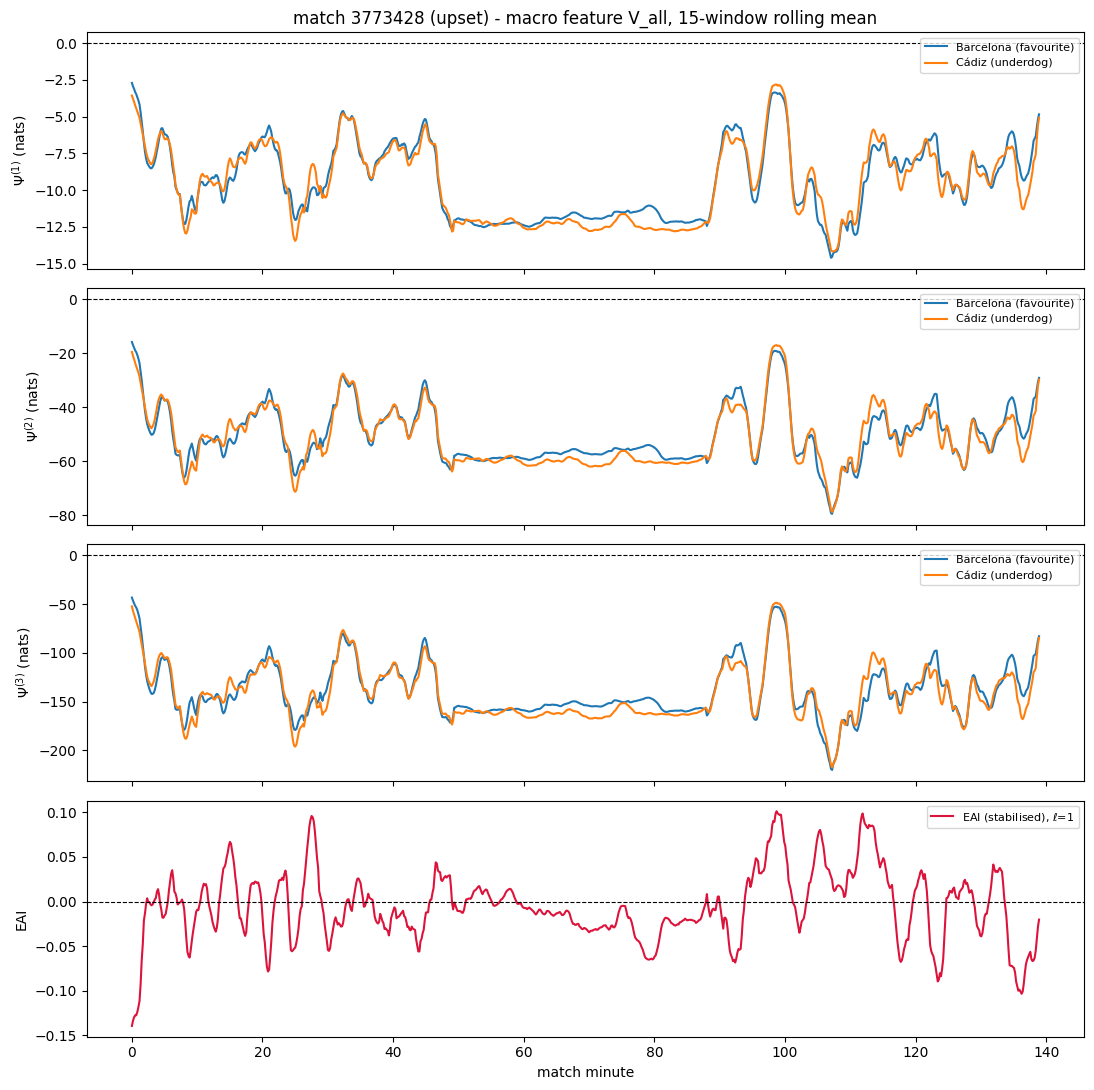

In [19]:
def plot_trajectories(match_id, feature="V_all", out_dir=CAUS_DIR, smooth=15):
    if not _HAS_PLT:
        print("matplotlib unavailable"); return
    d = load_caus([match_id], out_dir)
    if d.empty:
        print(f"no output for {match_id}"); return
    d = d[d.macro_feature == feature].sort_values("window_start")
    fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
    for ax, l in zip(axes[:3], (1, 2, 3)):
        for tm, g in d.groupby("team"):
            r = g.iloc[0].get("role")
            ax.plot(g.minute, g[f"psi_l{l}"].rolling(smooth, center=True, min_periods=1).mean(),
                    label=f"{tm}" + (f" ({r})" if r else ""))
        ax.axhline(0, ls="--", c="k", lw=.8)
        ax.set_ylabel(rf"$\Psi^{{({l})}}$ (nats)")
        ax.legend(fontsize=8, loc="upper right")
    g = d.drop_duplicates("window_start").sort_values("window_start")
    axes[3].plot(g.minute, g.eai_stab_l1.rolling(smooth, center=True, min_periods=1).mean(),
                 c="crimson", label=r"EAI (stabilised), $\ell$=1")
    axes[3].axhline(0, ls="--", c="k", lw=.8)
    axes[3].set_ylabel("EAI"); axes[3].set_xlabel("match minute")
    axes[3].legend(fontsize=8, loc="upper right")
    axes[0].set_title(f"match {match_id} ({d.outcome.iloc[0]}) - macro feature {feature}, "
                      f"{smooth}-window rolling mean")
    plt.tight_layout(); plt.show()

_up = computation_log[(computation_log.status == "ok") & (computation_log.outcome == "upset")]
plot_trajectories(int(_up.match_id.iloc[0]) if len(_up) else KSG_IDS[0])

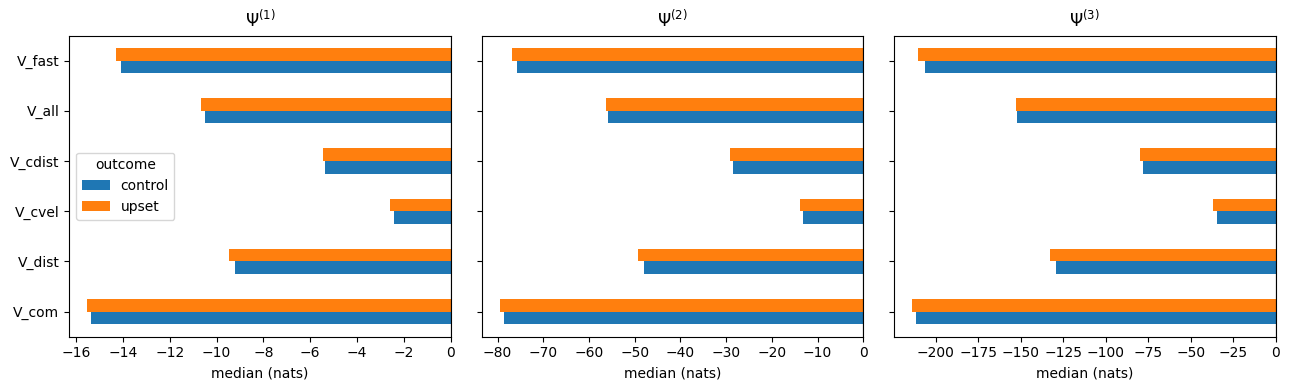

In [20]:
# === Psi by order: upset vs control, all macro features ======================
if _HAS_PLT and len(corpus):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    for ax, l in zip(axes, (1, 2, 3)):
        piv = corpus.pivot_table(index="macro_feature", columns="outcome",
                                 values=f"psi_l{l}", aggfunc="median").loc[MACRO_FEATURES]
        piv.plot.barh(ax=ax, legend=(l == 1))
        ax.axvline(0, c="k", lw=.8)
        ax.set_title(rf"$\Psi^{{({l})}}$"); ax.set_xlabel("median (nats)"); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

## 10. Output reference

`data/caus_emg/{match_id}_caus.csv` and `.parquet` — identical content, one row per
`(match_id, team, window_start, macro_feature)`.

`data/caus_emg/{match_id}_caus_log.json` — per-match computation log.

`data/caus_emg/computation_log.csv` — the corpus-level computation log deliverable.

### Carried into Sprint 5

* `psi_l1`, `psi_l2`, `psi_l3` per macro feature → RQ1 mixed-effects models, RQ2
  repeated-measures ANOVA (`Order × Match Type × Role`), RQ5 random-forest features.
* `eai_stab_l*` → RQ3 change-point detection (first sign change is the tipping point).
* `dc_ic` → RQ4 disruption analysis.
* `is_outlier`, `estimate_ok`, `eai_unstable`, `dc_unstable` → exclusion filters for the
  robustness checks in Giant_Killing §4.5.

### Caveats to carry forward

1. $\Psi$ is negative nearly everywhere. This is expected, not a bug: the whole-minus-sum
   family double-counts redundancy across all $n$ marginals (Rosas et al. §III A), and the
   effect grows with the number of subsets, so $\Psi^{(3)}\ll\Psi^{(2)}\ll\Psi^{(1)}$ by
   construction. **Compare $\Psi$ across matches, teams and time within a fixed order — do not
   read the sign as evidence against emergence, and do not compare magnitudes across orders.**
2. StatsBomb 360 freeze frames are event-sampled, so the 1 Hz grid interpolates between events;
   `n_eff` and `frac_valid` record how much of each window survived.
3. EAI, DC and SRR are emitted in their literal published form *and* stabilised. §5 gives the
   reasoning; Sprint 5 should analyse the stabilised columns and report the literal ones.
4. `psi_l3` uses the proximity-subsampled sum rescaled to the full triple count. §4.4 measures
   that bias; set `L3_STRATEGY = "full"` for the exhaustive sum.
5. All estimates use per-window standardised inputs (§1.2). `psi_parity` is the one column on
   raw inputs, and exists solely to prove the reconstruction reproduces Sprint 3 exactly.